
=== Processing G2D2_narrow_detect_simulated_cosi_0p00_outfile.h5 ===


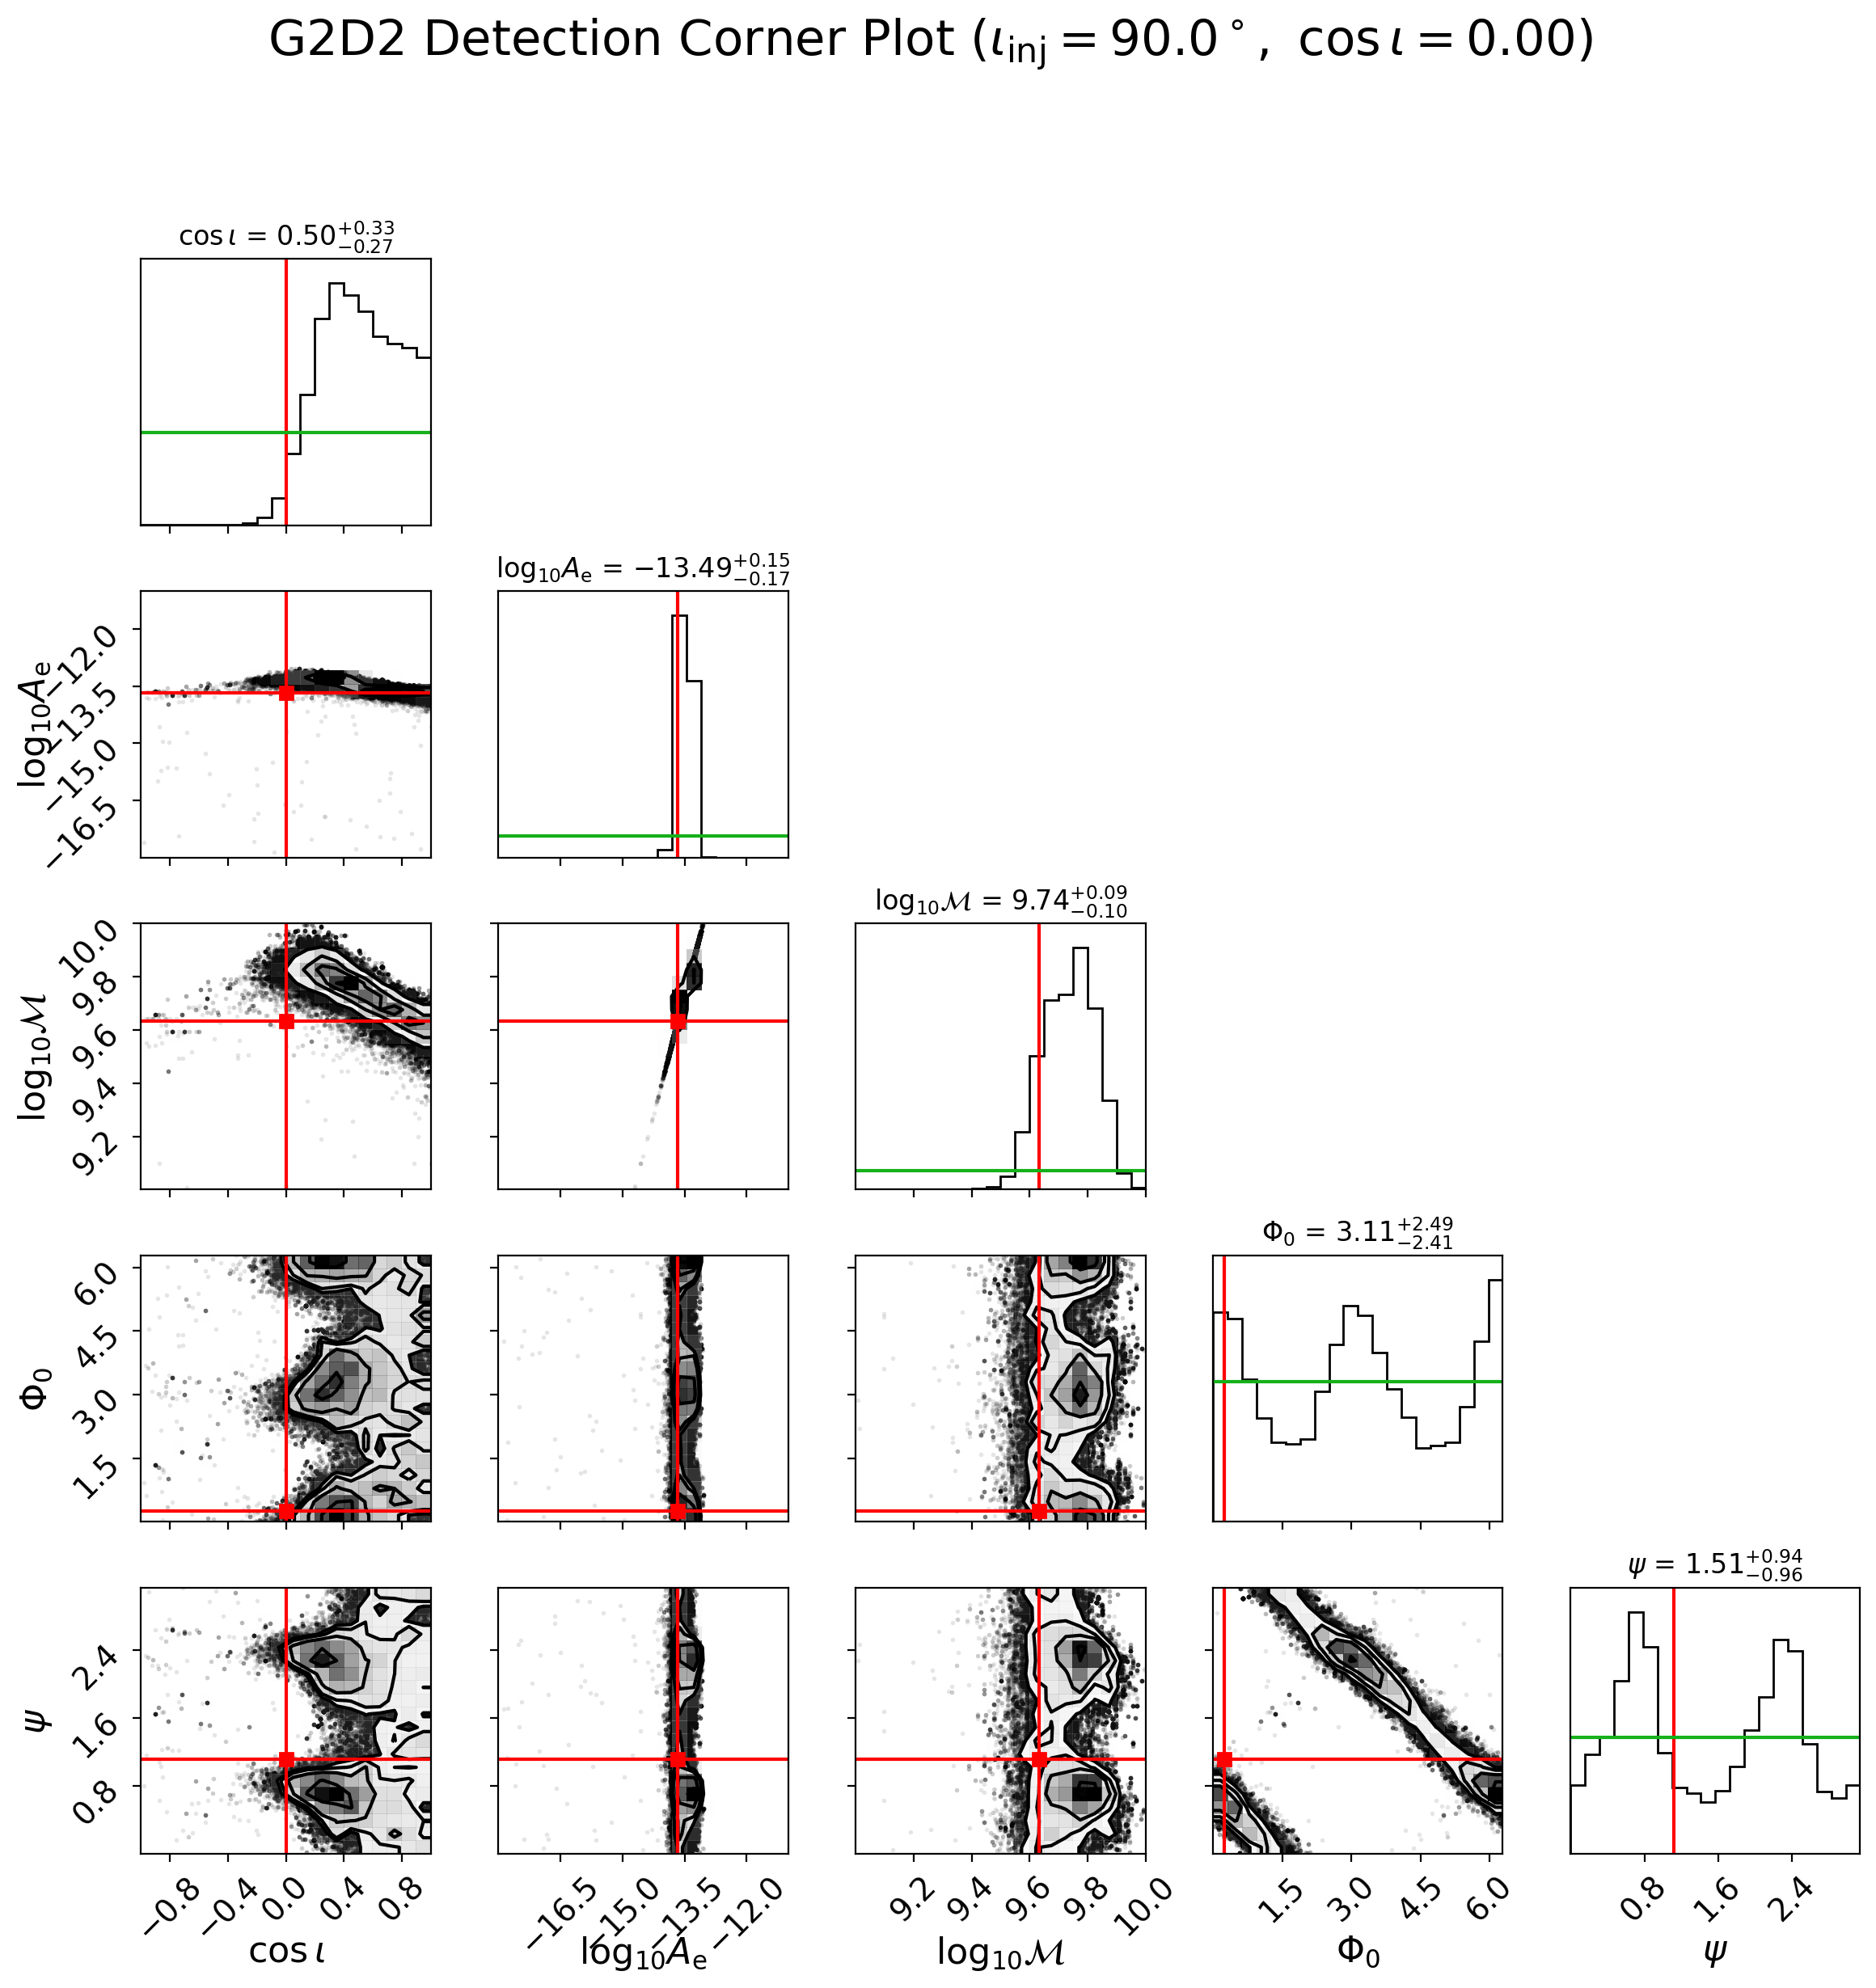


=== Processing G2D2_narrow_detect_simulated_cosi_0p71_outfile.h5 ===


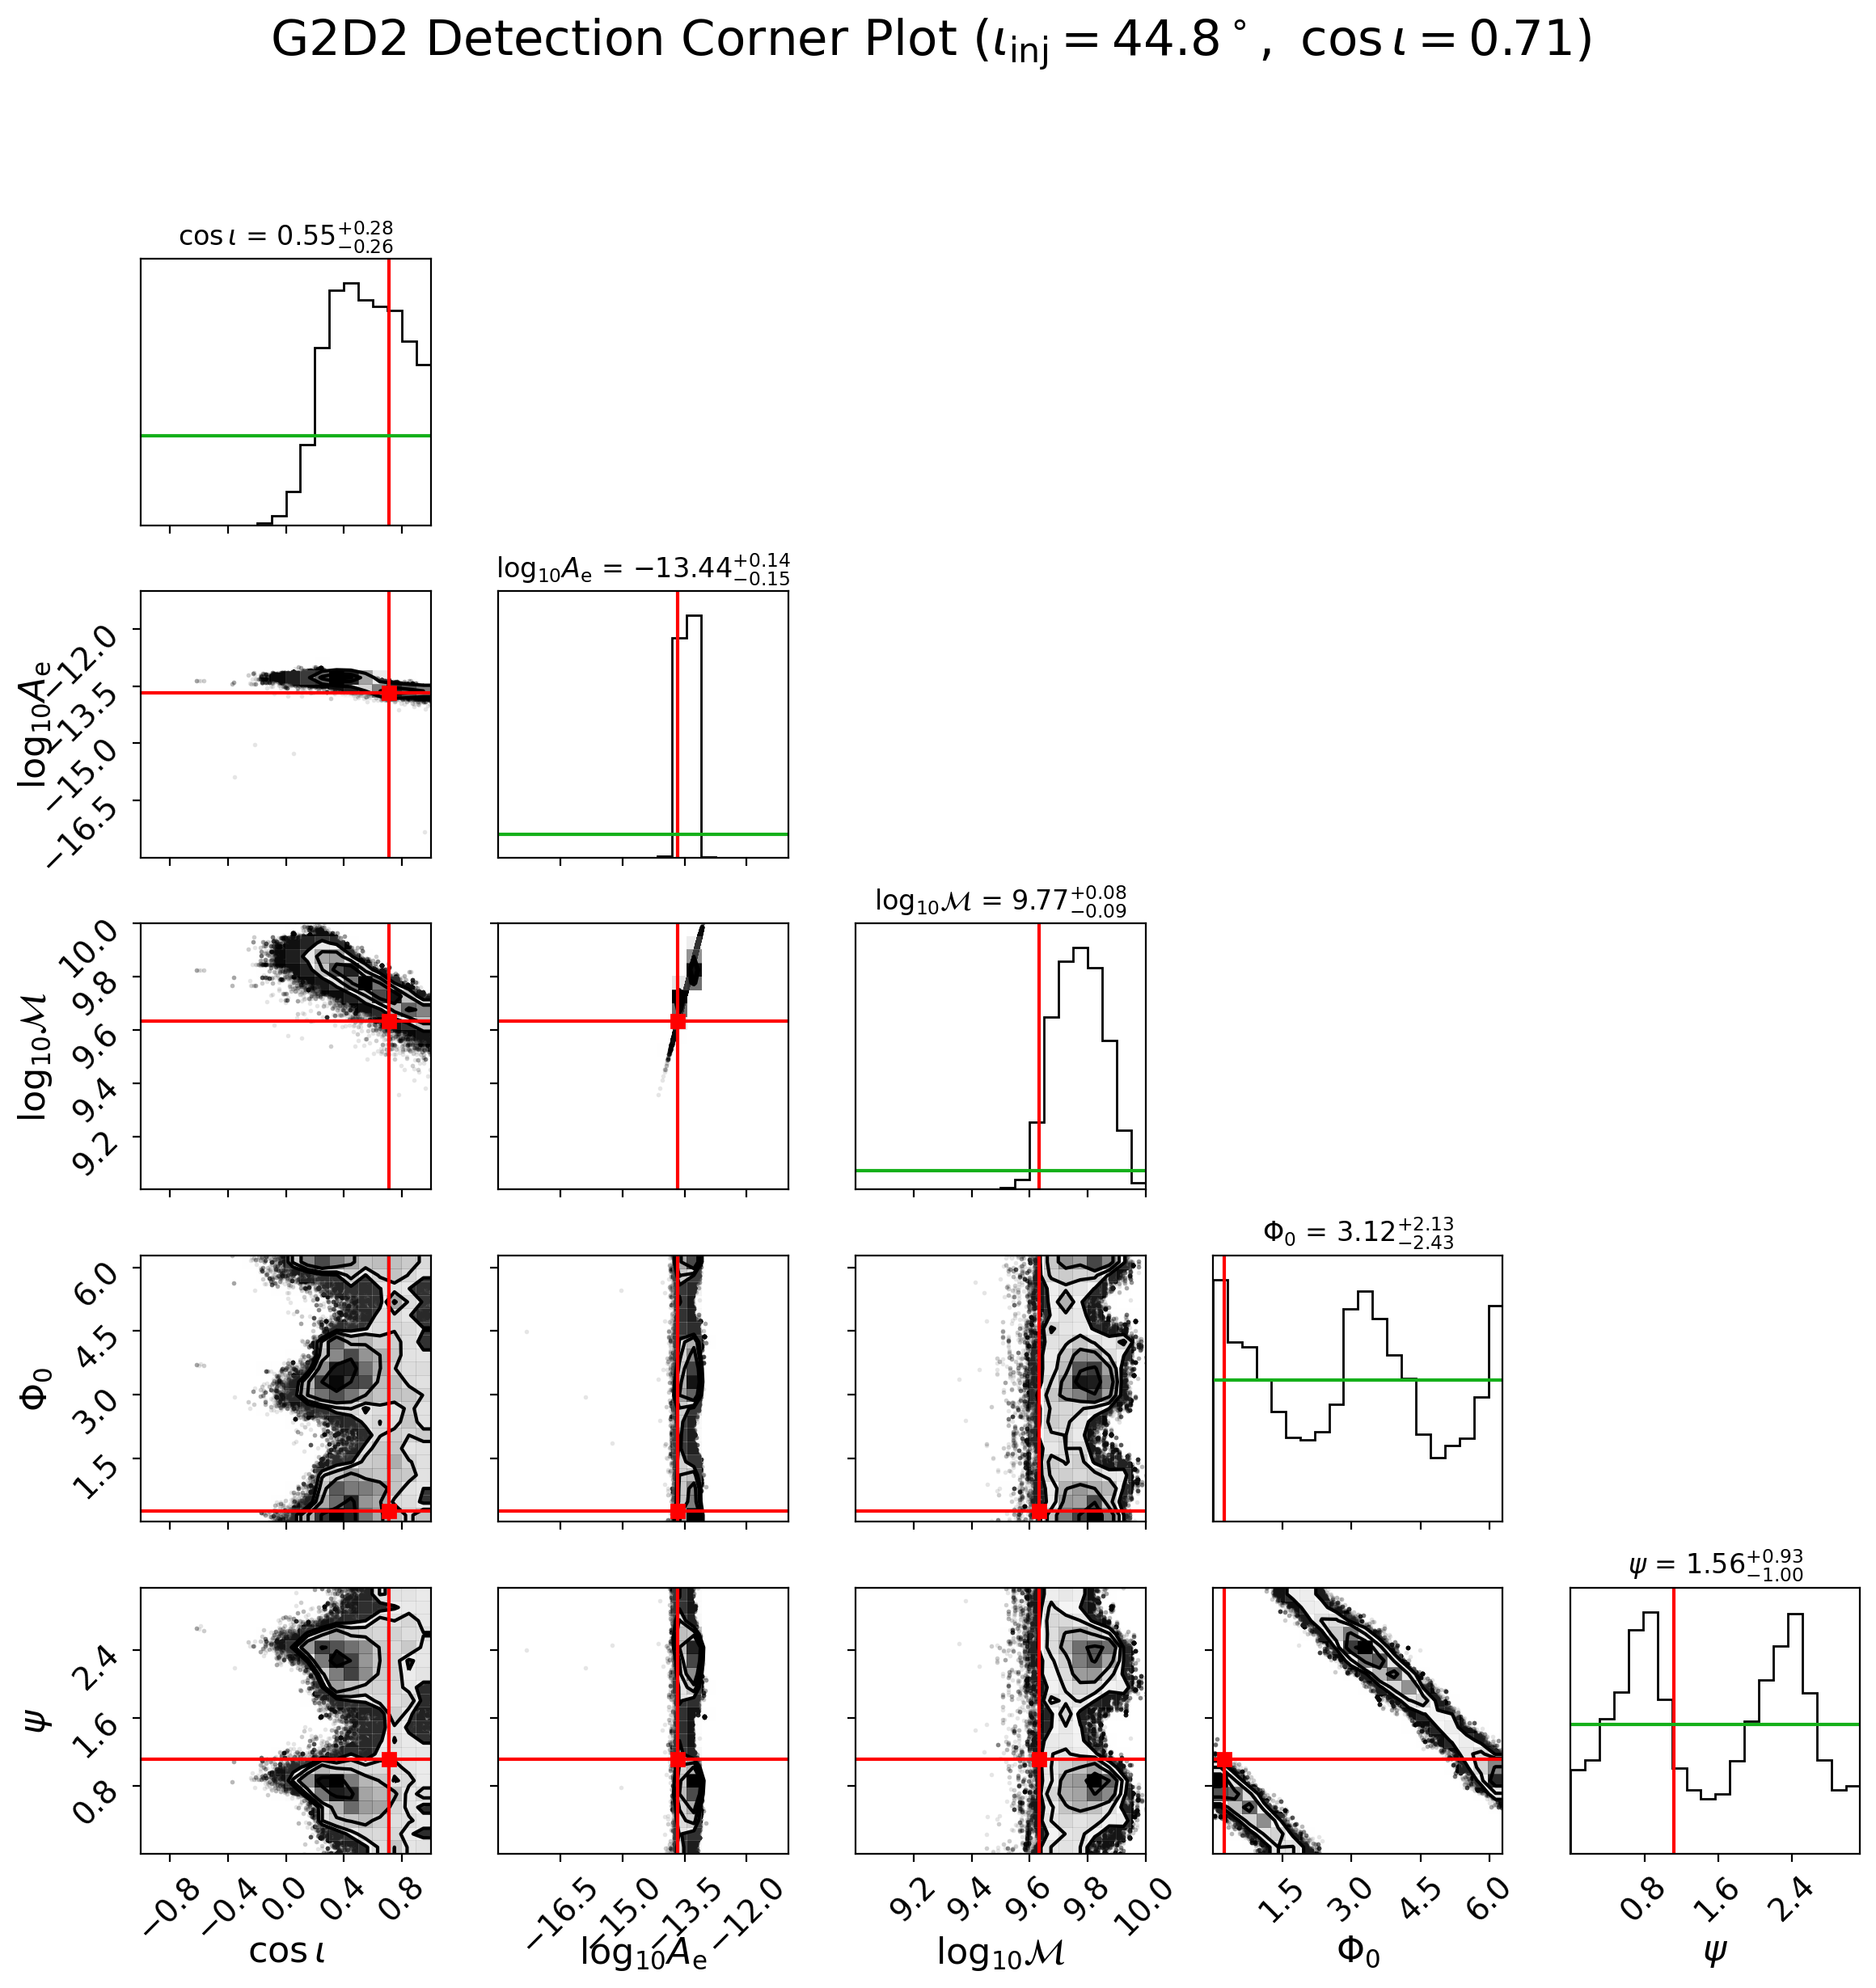


=== Processing G2D2_narrow_detect_simulated_cosi_1p00_outfile.h5 ===


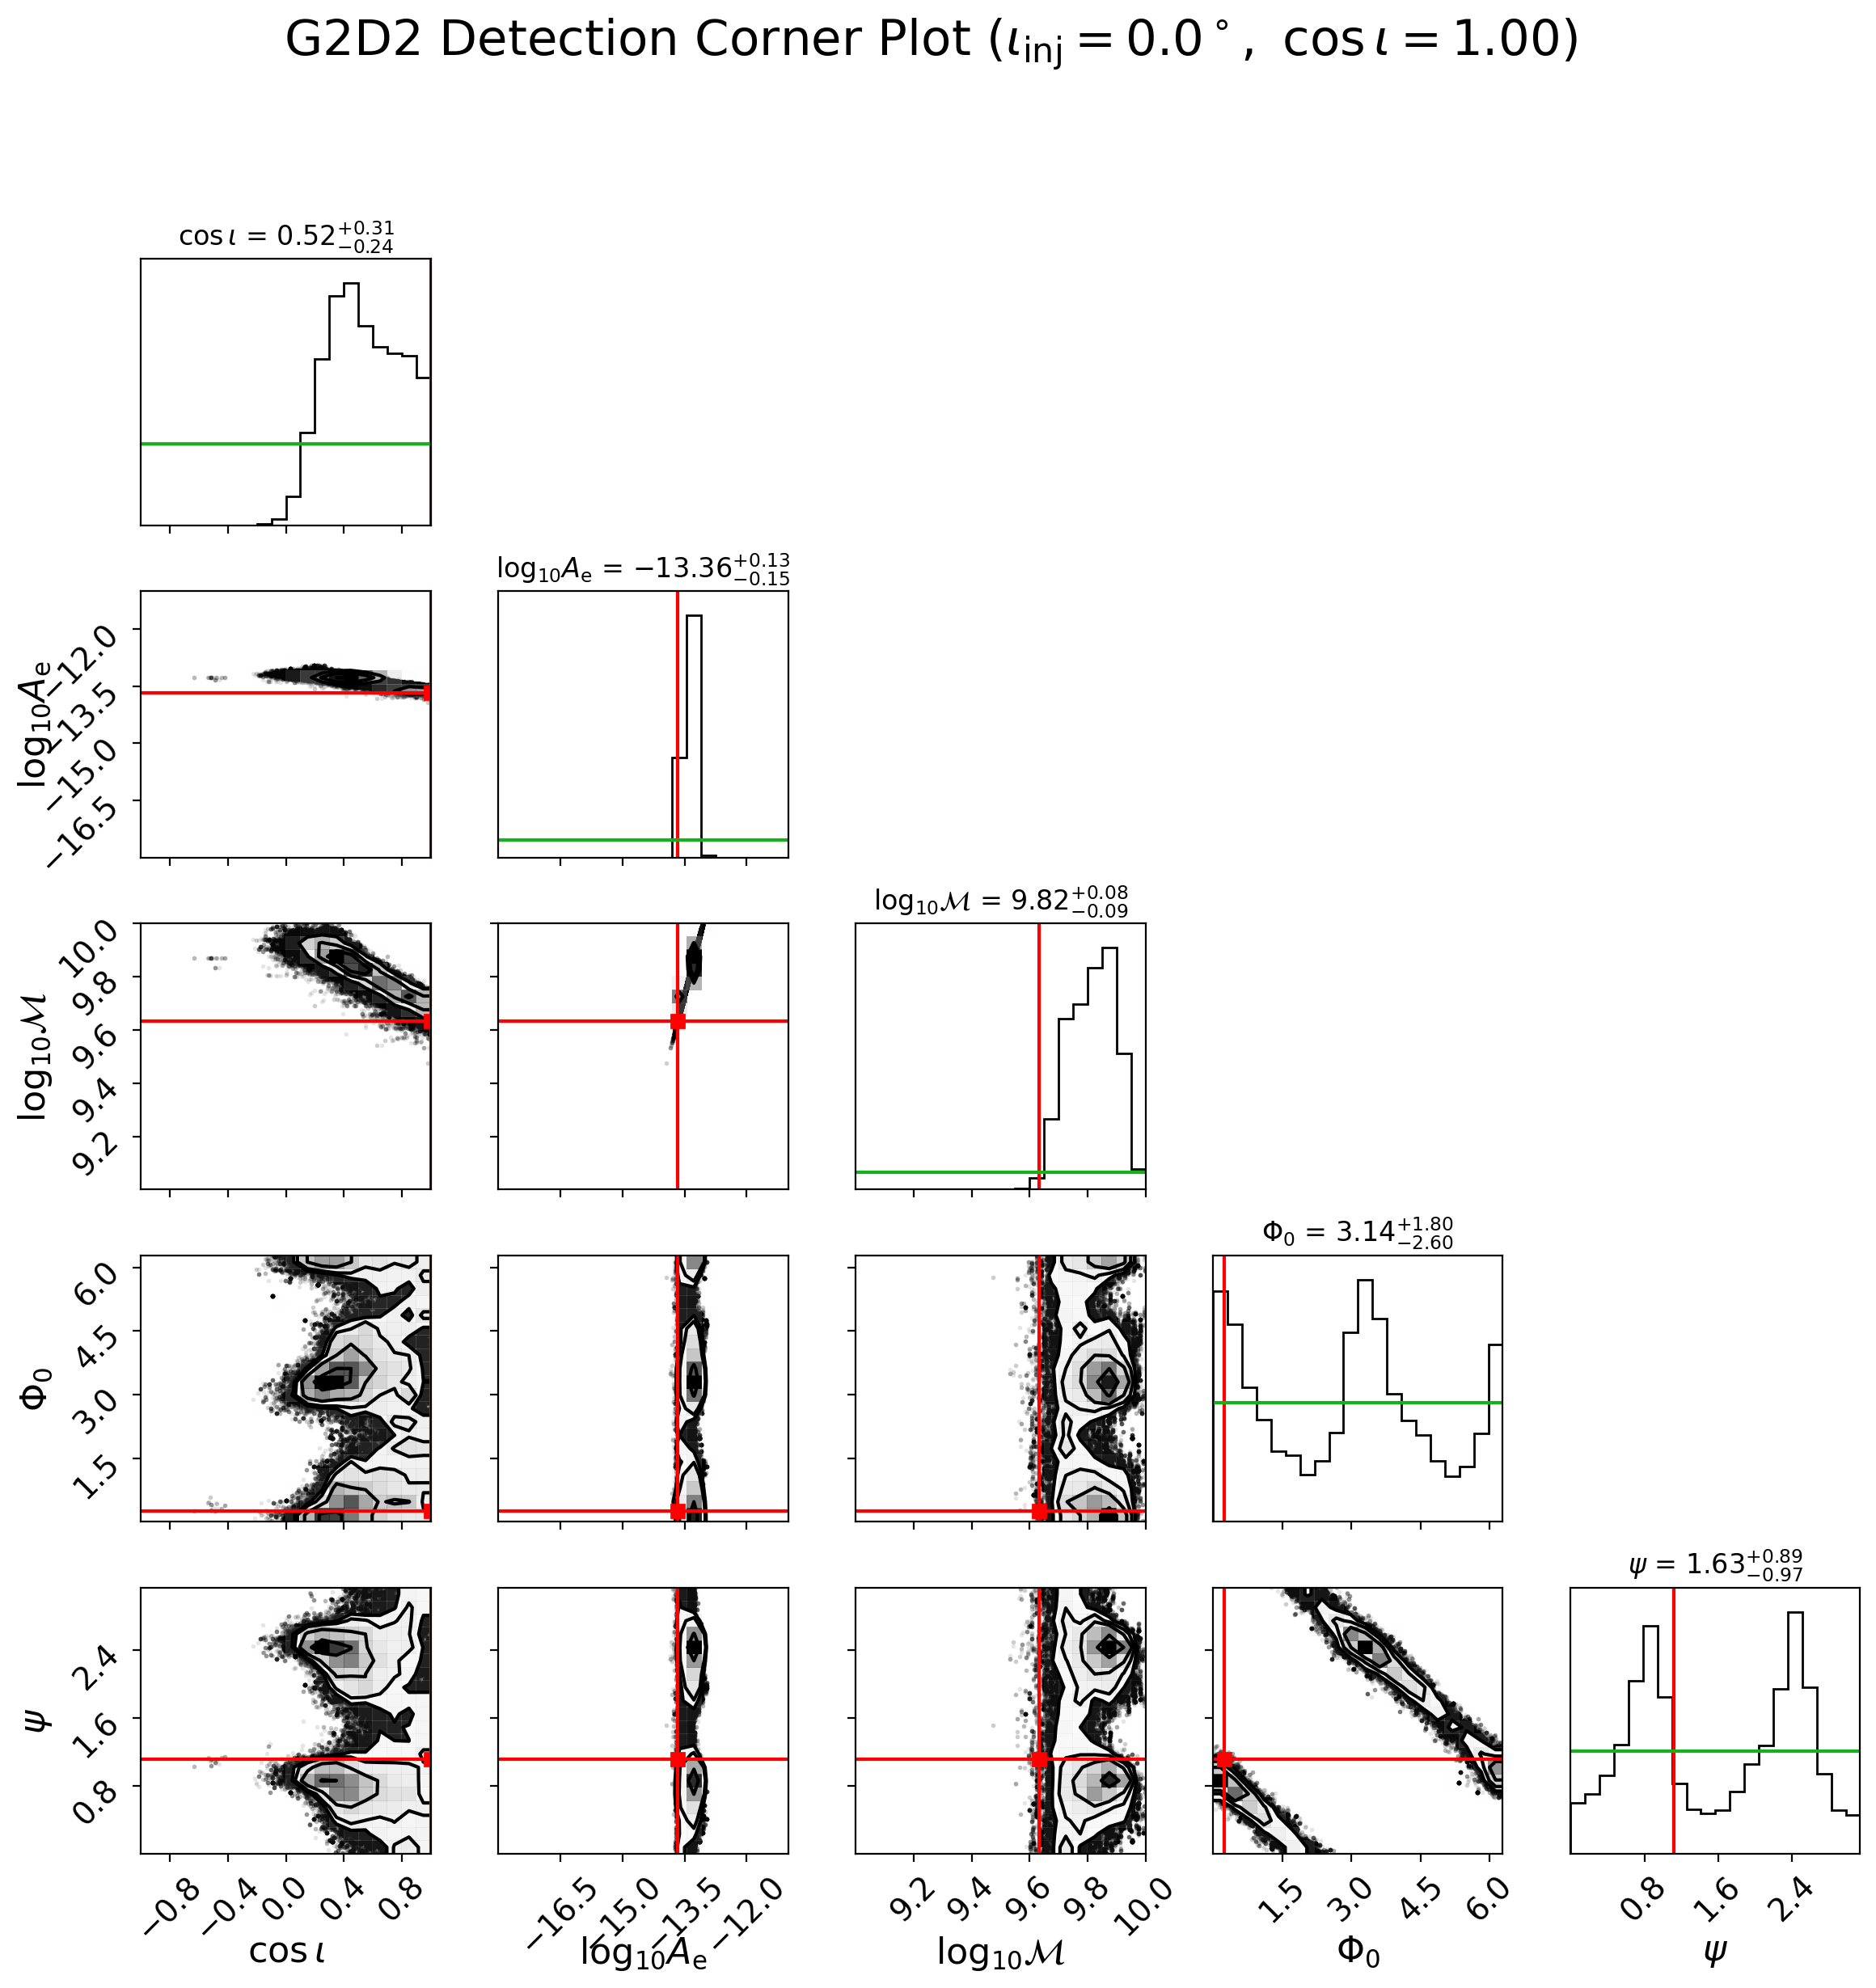

In [1]:
# ================================================================
# CORNER PLOTS FOR DIFFERENT INCLINATIONS (cos i sweep)
# ================================================================

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

import numpy as np
import h5py
import corner
import matplotlib.pyplot as plt
import re
from pathlib import Path

# ================================================================
# USER SETTINGS
# ================================================================

base_dir = Path("/scratch/na00078/projects/IPTA_MDC2/h5_files/")
files = [
    "G2D2_narrow_detect_simulated_cosi_0p00_outfile.h5",
    "G2D2_narrow_detect_simulated_cosi_0p71_outfile.h5",
    "G2D2_narrow_detect_simulated_cosi_1p00_outfile.h5",
]

target_d_L = 75.4  # Mpc

# True (injection) parameters that DO NOT change
xxx0 = {
    "0_cos_gwtheta": np.cos(0.6387905062299246),
    "0_gwphi": 3.3335788713091694,
    "0_log10_fgw": np.log10(3.7e-9),
    "0_log10_h": -13.668773493298787,
    "0_log10_mc": np.log10(4.3e9),
    "phase0": 0.24434609527920614,
    "psi": 1.1187560505283651,  # fixed
    "distance": 75.4,
}

labels = [
    r"$\cos \iota$",
    r"$\log_{10} A_{\rm e}$",
    r"$\log_{10} {\cal M}$",
    r"$\Phi_0$",
    r"$\psi$"
]

label_to_key = {
    r"$\cos \iota$": "0_cos_inc",
    r"$\log_{10} A_{\rm e}$": "0_log10_h",
    r"$\log_{10} {\cal M}$": "0_log10_mc",
    r"$\Phi_0$": "phase0",
    r"$\psi$": "psi",
}

ranges = [(-1,1), (-18,-11), (9,10), (0,2*np.pi), (0,np.pi)]

# constants for d_L reconstruction
megaparsec = 3.086e+22
speed_of_light = 299792458.0
T_sun = 1.327124400e20 / speed_of_light**3

# ================================================================
# PROCESS EACH FILE
# ================================================================

for fname in files:
    infile = base_dir / fname
    print(f"\n=== Processing {infile.name} ===")

    # ------------------------------------------------------------
    # Extract cos(i) from filename
    # ------------------------------------------------------------
    cosi_match = re.search(r"cosi_([0-9p]+)", fname)
    if cosi_match:
        cosi_str = cosi_match.group(1).replace("p", ".")
        try:
            cosi_val = float(cosi_str)
        except ValueError:
            cosi_val = np.nan
    else:
        cosi_val = np.nan

    inc_val = np.arccos(cosi_val)   # inclination in radians
    xxx0["0_cos_inc"] = cosi_val    # truth for this run

    # generate truth vector
    truths = [xxx0[label_to_key[l]] for l in labels]

    # ------------------------------------------------------------
    # Load samples
    # ------------------------------------------------------------
    with h5py.File(infile, "r") as f:
        samples_cold = f["samples_cold"][:, :, :8]  # chain 0, first 8 params
        par_names = [x.decode("UTF-8") for x in f["par_names"]]

    # Extract parameters needed for d_L
    h_amp = 10 ** samples_cold[0][:, 4]
    fgw = 10 ** samples_cold[0][:, 3]
    mc = 10 ** samples_cold[0][:, 5]

    # reconstruct distance
    log10_d_L = np.log10(
        2 * (mc * T_sun)**(5/3) * (np.pi * fgw)**(2/3)
        / h_amp * speed_of_light / megaparsec
    )

    d_L_min = target_d_L * 0.99
    d_L_max = target_d_L * 1.01
    d_L_mask = np.where((10**log10_d_L >= d_L_min) & (10**log10_d_L <= d_L_max))[0]

    # gather parameters for plotting
    samples2plot = np.concatenate(
        (samples_cold[0][:, :8], np.array([log10_d_L]).T), axis=1
    )

    samples2plot_detect = np.vstack((
        samples2plot[d_L_mask,1],   # log10 h
        samples2plot[d_L_mask,4],   # log10 Ae
        samples2plot[d_L_mask,5],   # log10 Mc
        samples2plot[d_L_mask,6],   # phase0
        samples2plot[d_L_mask,7],   # psi
    )).T

    # BUT the first parameter MUST be cos(i)
    samples2plot_detect[:,0] = samples2plot[d_L_mask,1]  # overwrite with cos(i)
    samples2plot_detect[:,0] = samples_cold[0][d_L_mask,1]

    # ------------------------------------------------------------
    # Corner plot
    # ------------------------------------------------------------
    fig = corner.corner(
        samples2plot_detect,
        labels=labels,
        show_titles=True,
        range=ranges,
        truths=truths,
        truth_color="red",
        hist_kwargs={"density": True},
    )

    # improve readability
    for ax in fig.get_axes():
        ax.tick_params(axis='both', labelsize=14)
        ax.xaxis.label.set_size(16)
        ax.yaxis.label.set_size(16)

    # ------------------------------------------------------------
    # Prior lines on diagonal
    # ------------------------------------------------------------
    for i, ax in enumerate(fig.axes):
        if i == 0:  # cos(i)
            Xs = np.linspace(-1, 1)
            ax.plot(Xs, Xs*0 + 0.5, color="xkcd:green")

        elif i == (len(labels)+1):  # log10 Ae
            Xs = np.linspace(-18, -11)
            ax.plot(Xs, Xs*0 + 1/7, color="xkcd:green")

        elif i == 2*(len(labels)+1):  # log10 Mc
            Xs = np.linspace(9, 10)
            ax.plot(Xs, Xs*0 + 1/3, color="xkcd:green")

        elif i == 3*(len(labels)+1):  # phase0
            Xs = np.linspace(0, 2*np.pi)
            ax.plot(Xs, Xs*0 + 1/(2*np.pi), color="xkcd:green")

        elif i == 4*(len(labels)+1):  # psi
            Xs = np.linspace(0, np.pi)
            ax.plot(Xs, Xs*0 + 1/np.pi, color="xkcd:green")

    # ------------------------------------------------------------
    # Title
    # ------------------------------------------------------------
    fig.suptitle(
        rf"G2D2 Detection Corner Plot ($\iota_{{\rm inj}} = {np.degrees(inc_val):.1f}^\circ,\ \cos\iota={cosi_val:.2f}$)",
        fontsize=22, y=1.05
    )

    plt.tight_layout()
    plt.show()
